# Figure 3

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False

# Specify data structure (30°/s edges only):
fs = 1000 # sampling frequency (Hz)
stims = ['on', 'off'] # stimuli
dirs = ['pd', 'nd']   # directions
tf = 8000             # timeframe (ms)

# Load input cell voltage data:
Mi9a = np.load('fig3_Mi9.npy')
Tm3a = np.load('fig3_Tm3.npy')
Mi1a = np.load('fig3_Mi1.npy')
Mi4a = np.load('fig3_Mi4.npy')
C3a = np.load('fig3_C3.npy')

# Average input cell voltage data:
Mi9_ = np.nanmean(Mi9a, axis=1)
Tm3_ = np.nanmean(Tm3a, axis=1)
Mi1_ = np.nanmean(Mi1a, axis=1)
Mi4_ = np.nanmean(Mi4a, axis=1)
C3_ = np.nanmean(C3a, axis=1)

# Load T4 cell voltage data:
T4va = np.load('fig3_T4v.npy')

# Average T4 cell voltage data:
T4v = T4va.mean(0)
T4v_sem = stats.sem(T4va, axis =0, nan_policy='omit')

# Load LED data:
led = np.load('fig3_led.npy')

# Initialize arrays:
Mi9 = np.full((len(stims), len(dirs), tf), np.nan)
Tm3 = np.full((len(stims), len(dirs), tf), np.nan)
Mi1 = np.full((len(stims), len(dirs), tf), np.nan)
Mi4 = np.full((len(stims), len(dirs), tf), np.nan)
C3 = np.full((len(stims), len(dirs), tf), np.nan)
LED = np.full((len(stims), len(dirs), tf), np.nan)
T4model = np.full_like(T4v, np.nan)

gMi9 = np.full_like(Mi9, np.nan)
gTm3 = np.full_like(Tm3, np.nan)
gMi1 = np.full_like(Mi1, np.nan)
gMi4 = np.full_like(Mi4, np.nan)
gC3 = np.full_like(C3, np.nan)

gtotal = np.full_like(T4v, np.nan)

# Normalize and shift data for PD and ND:
def normalize(a):
    anorm=a-np.min(a)
    anorm=anorm/np.max(anorm)
    return anorm

def shift_data(data, shift):
    shifted = np.roll(data, shift)
    if shift > 0:
        shifted[0:shift] = data[0]
    if shift < 0:
        shifted[int(len(data))+shift:int(len(data))] = data[-1]
    return shifted

def pdnd_shift(Mi9_=normalize(Mi9_), Tm3_=normalize(Tm3_), Mi1_=normalize(Mi1_), Mi4_=normalize(Mi4_), C3_=normalize(C3_)):
    for s in range(len(stims)):
        shift = int(4.8*fs/30) # assuming an inter-ommatidial angle of 4.8°
        for idxd, d in enumerate(dirs):
            Tm3[s,idxd] = Tm3_[s]
            Mi1[s,idxd] = Mi1_[s]
            
            if d == 'pd':
                Mi9[s,idxd] = shift_data(Mi9_[s], -shift)
                Mi4[s,idxd] = shift_data(Mi4_[s], +shift)
                C3[s,idxd] = shift_data(C3_[s], +shift)
                
            elif d == 'nd':
                Mi9[s,idxd] = shift_data(Mi9_[s], +shift)
                Mi4[s,idxd] = shift_data(Mi4_[s], -shift)
                C3[s,idxd] = shift_data(C3_[s], -shift)                 
                
    return Mi9, Tm3, Mi1, Mi4, C3

# Shift:
Mi9, Tm3, Mi1, Mi4, C3 = pdnd_shift()


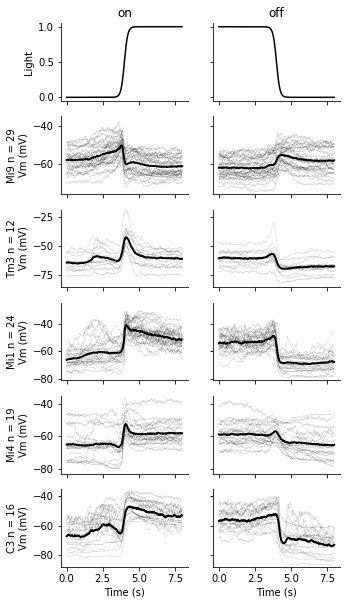

In [2]:
# Figure 3a (input traces):
cells = [Mi9a, Tm3a, Mi1a, Mi4a, C3a]
names = ['Mi9', 'Tm3', 'Mi1', 'Mi4', 'C3']
cs = ['forestgreen', 'orange', 'C3', 'C0', 'cadetblue']
dsf = 1 # downsampling factor for plotting (1 means no downsampling)
fs = 1000/dsf

fig, ax = plt.subplots(len(cells)+1,len(stims), figsize=(5,10), sharex=True, sharey=False)

# Plot LED traces:
for idxs, s in enumerate(stims):
    y =  led[idxs,0,::dsf]
    time = np.linspace(0,len(y)/fs,len(y))
    ax[0, idxs].plot(time, y, c='k')
    ax[0, 1].tick_params(labelleft=False)
    ax[0, 0].set_ylabel("Light")
    ax[0, idxs].set_title(stims[idxs])
    
for idxc, c in enumerate(cells):
    for idxs, s in enumerate(stims):
        # Plot single-cell traces:
        for e in np.arange(c.shape[1]):
            y = c[idxs,e]
            time = np.linspace(0,len(y[::dsf])/fs,len(y[::dsf]))
            ax[idxc+1, idxs].plot(time, y[::dsf], c='k', linewidth=0.5, alpha=0.15)
            
        # Plot average traces:   
        y = c[idxs].mean(0)
        time = np.linspace(0,len(y[::dsf])/fs,len(y[::dsf]))
        ax[idxc+1, idxs].plot(time, y[::dsf], c='k', linewidth=2)
        ax[idxc+1, 1].tick_params(labelleft=False)
        ax[idxc+1, 0].set_ylabel("{0} n = {1}\nVm (mV)".format(names[idxc], cells[idxc].shape[1]))
    
    # Set y axis limits:    
    for i in range(2):
        ax[1, i].set_ylim(-76, -35)
        ax[2, i].set_ylim(-85, -19)
        ax[3, i].set_ylim(-81, -25)
        ax[4, i].set_ylim(-83, -35)
        ax[5, i].set_ylim(-88, -35)
        
        ax[-1,i].set_xlabel("Time (s)")
        
#plt.savefig('fig3a.pdf')

In [3]:
# Model:
# Initialize free parameters:
# Synaptic weights/gains:
Mi9gain = 0.92
Tm3gain = 0.35
Mi1gain = 0.65
Mi4gain = 1.1
C3gain = 1.49

# Thresholds:
Mi9trld = 0.20
Tm3trld = 0.35
Mi1trld = 0.88 
Mi4trld = 0.44
C3trld = 0.70

# Leak conductance:
gleak = 0.50
Eleak = -65.0

# Constants:
EGlu = -71.0    # Glutamate current reversal potential (mV)
EGABA   = -68.0 # GABA current reversal potential (mV)
EnAChR = -21.0  # Nicotinic acetycholine current reversal potential (mV)

# Model:
vs = [Mi9, Tm3, Mi1, Mi4, C3] # input cell voltages
gs = [gMi9, gTm3, gMi1, gMi4, gC3] # conductances
onoff = [1, 1, 1, 1, 1, 1] # To switch cells on/off 1/0 [Mi9, Mi1, Tm3, Mi4, C3]:

params = np.array([Mi9gain, Tm3gain, Mi1gain, Mi4gain, C3gain,
                       Mi9trld, Tm3trld, Mi1trld, Mi4trld, C3trld,
                       Eleak, gleak])

# Rectilinear transfer function:
def rect(x,thrld):
    result = x - thrld
    result = result * (result>0)
    result = result + thrld
    return result

# Run the simulation:
def run_model(onoff=[1,1,1,1,1], params=params):
    # Assigns conductances:
    params = np.asarray(params)

    for idx, g in enumerate(gs):
        g[:] = onoff[idx] * params[idx] * rect(vs[idx][:] - params[idx+5], 0)
    T4model[:] = EGlu * gMi9 + EnAChR * (gTm3+gMi1) + EGABA * (gMi4+gC3) + params[10] * params[11]
        
    gtotal[:] = gMi1 + gMi4 + gMi9 + gC3 + gTm3 + gleak
    T4model[:] = T4model[:] / gtotal[:] 
    
    return T4model

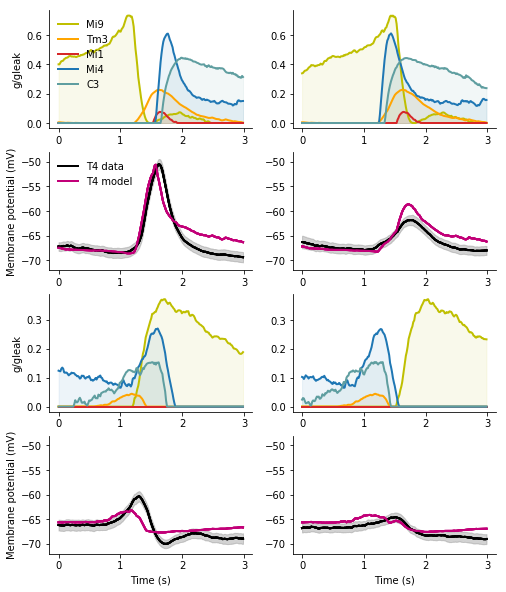

In [4]:
# Figure 3b:
ds = 15  # downsample for plotting
m = 2500 # margin

# Run simulation:
y_model = run_model(onoff = [1, 1, 1, 1, 1], params=params)

# Plot:
fig, ax = plt.subplots(4,2, figsize=(8,10))
time = np.arange(0,len(T4v[0,0,m:-m])/fs,0.001)

labels = ['Mi9', 'Tm3', 'Mi1', 'Mi4', 'C3']
colors = ['y', 'orange', 'C3', 'C0', 'cadetblue']

# plot observation
for idxs, s in enumerate(stims):
    for idxg, g in enumerate(gs):
        for idxd, d in enumerate(dirs):
            ax[0+idxs*2,idxd].plot(time[::ds], g[0+idxs,idxd,m:-m:ds], lw=2, c=colors[idxg], label=labels[idxg])
            ax[0+idxs*2,idxd].fill_between(time[::ds], g[0+idxs,idxd,m:-m:ds], np.full_like(g[0+idxs,idxd,m:-m:ds], 0), color=colors[idxg], alpha=0.08)
            ax[1+idxs*2,idxd].plot(time[::ds], T4v[0+idxs,idxd,m:-m:ds], lw=2, c='k', label='T4 data')
            ax[1+idxs*2,idxd].fill_between(time[::ds], T4v[0+idxs,idxd,m:-m:ds] - T4v_sem[0+idxs,idxd,m:-m:ds],
                                           T4v[0+idxs,idxd,m:-m:ds] + T4v_sem[0+idxs,idxd,m:-m:ds], color='grey', alpha=0.08)
            ax[1+idxs*2,idxd].plot(time[::ds], y_model[0+idxs,idxd,m:-m:ds], lw=2, c='#C20078', label='T4 model')
            #bx = ax[1+idxs*2,idxd].twinx()
            #bx.plot(time, T4r[0+idxs,idxd,m:-m], lw=2, linestyle= ':', c='g')
            #bx.plot(time, rin[0+idxs,idxd,m:-m], lw=2, linestyle= ':', c='g')
            ax[1+idxs*2,idxd].set_ylim(-72, -48)
            
ax[0,0].legend(frameon=False)
ax[1,0].legend(frameon=False, labels = ['T4 data', 'T4 model'])


for i in [0,2]:
    ax[i,0].set_ylabel('g/gleak')
    
for i in [1,3]:
    ax[i,0].set_ylabel('Membrane potential (mV)')
    
for i in [0,1]:
    ax[3,i].set_xlabel('Time (s)')
#plt.savefig('fig3b.pdf')